# Connectome Fingerprinting — a guided walkthrough

**Can you identify a person from their brain's wiring pattern?**

Every brain has a pattern of *which regions tend to activate together*. Finn et al.
(2015, *Nature Neuroscience*) found that this pattern is stable and personal — like a
fingerprint. This notebook rebuilds that result from scratch on **339 people**, each
scanned on **two different days**, and then pushes past it.

> Take a person's brain "fingerprint" from Day 1. Looking only at the 339 fingerprints
> from Day 2, can we correctly pick that same person out?

Guessing at random would be right **1 in 339 ≈ 0.3%** of the time. We finish at **91.6%** —
but the first honest attempt only manages 31%, and *closing that gap* is the most
instructive part of the exercise. Then we ask three follow-up questions: which parts of the
brain carry identity, whether identity survives a change of mental task, and whether
smarter people are easier to identify.

You don't need any neuroscience to follow along. Underneath the biology it's a biometric
**identification** problem: high-dimensional features, a similarity search, and careful
handling of confounds.

## The method, in four small steps

1. **A fingerprint** — for every *pair* of the 360 brain regions, how strongly they rise
   and fall together over the scan (a correlation). That's `360 × 359 / 2 = 64,620`
   numbers per person, per session.
2. **Similarity** — how alike two fingerprints are (a correlation between two lists of
   64,620 numbers).
3. **Identification** — for each person's Day-1 fingerprint, guess that their
   most-similar Day-2 fingerprint is them.
4. **Accuracy** — the fraction we guess correctly.

That's the entire method. Everything else here is either making those four steps work
properly, or asking what they tell us.

## How to read this

Run the cells top to bottom. Each step is a short explanation, a small piece of code, then
the number or picture it produces. The first cell downloads ~12 GB and takes a while;
after that it's a couple of minutes of compute.

**This notebook is self-contained** — it fetches its own data and needs no other files, so
it runs on Colab as-is. It's the *narrated* version of a pipeline that also exists as
plain scripts (`analyzer.py` for the numbers, `visualiser.py` for the figures); the code
here is the same code. Nothing here writes to disk.

---
# Prerequisites

## Download the HCP dataset

We use the [Neuromatch Academy](https://compneuro.neuromatch.io/) curated release of the
**Human Connectome Project** — 339 people, each with 4 resting-state scans (two per day)
and 7 in-scanner tasks × 2 runs, all summarised into the 360-region Glasser atlas.

This is the downloader from the repo's `download.py`, inlined so the notebook is
self-contained — upload just this file to Colab and it will fetch its own data. It pulls
~12 GB from OSF into `./data/`:

| File | Size | Unpacks to | Contents |
|---|---|---|---|
| `hcp_rest.tgz` | ~1.6 GB | `data/hcp_rest/` | resting-state scans (4 per person) |
| `hcp_task.tgz` | ~1.3 GB | `data/hcp_task/` | 7 tasks × 2 runs, plus `regions.npy` |
| `hcp_covariates.tgz` | ~0.8 MB | `data/hcp/` | behaviour CSVs (the intelligence composite) |
| `atlas.npz` | ~91 KB | `data/atlas.npz` | parcel coords / vertex labels |

**This takes a while** — it's by far the slowest cell here, and the rest of the notebook is
only a couple of minutes once it's done. It's safe to re-run: anything already present is
skipped, so an interrupted download just picks up where it stopped.

In [ ]:
import os, urllib.request, tarfile

DATA = "data"

# (filename, OSF download url, dir it extracts to under ./data — or None if it's a plain file)
FILES = [
    ("hcp_rest.tgz",       "https://osf.io/bqp7m/download", "hcp_rest"),
    ("hcp_task.tgz",       "https://osf.io/s4h8j/download", "hcp_task"),
    ("hcp_covariates.tgz", "https://osf.io/x5p4g/download", "hcp"),
    ("atlas.npz",          "https://osf.io/j5kuc/download", None),
]


def fetch(fname, url, extracted):
    """Download <fname> from OSF into ./data and extract it if it's an archive.
    Skips whatever is already in place, so this is safe to run repeatedly."""
    path = os.path.join(DATA, fname)
    done = os.path.join(DATA, extracted) if extracted else path
    if os.path.exists(done):
        print(f"  {fname:20s} already present -> {done}")
        return

    if not os.path.isfile(path):
        print(f"  {fname:20s} downloading (this can take a few minutes)...")
        urllib.request.urlretrieve(url, path)

    if extracted:
        print(f"  {fname:20s} extracting -> data/{extracted}/")
        with tarfile.open(path) as t:
            t.extractall(DATA, filter="data")


os.makedirs(DATA, exist_ok=True)
print(f"Fetching HCP dataset into ./{DATA}/")
for fname, url, extracted in FILES:
    fetch(fname, url, extracted)
print("Done. Next: run the cells below.")

Fetching HCP dataset into ./data/
  hcp_rest.tgz         downloading (this can take a few minutes)...
  hcp_rest.tgz         extracting -> data/hcp_rest/
  hcp_task.tgz         downloading (this can take a few minutes)...
  hcp_task.tgz         extracting -> data/hcp_task/
  hcp_covariates.tgz   downloading (this can take a few minutes)...
  hcp_covariates.tgz   extracting -> data/hcp/
  atlas.npz            downloading (this can take a few minutes)...
Done. Next: run the cells below.


## Import Libraries

In [ ]:
%matplotlib inline

import os
from enum import IntEnum
from collections.abc import Callable

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

## Config and Constants

The two numbers that shape everything: **339 people** and **360 regions**.

`IU` deserves a note. A person's 360×360 correlation grid is symmetric — the correlation of
region A with region B is the same as B with A — and its diagonal is all 1s (every region
correlates perfectly with itself). So a bit over half the grid is redundant. `IU` indexes
the **upper triangle**, and `grid[IU]` pulls out the 64,620 numbers that actually carry
information. That flat list *is* the fingerprint.

In [ ]:
SURFACE = "#fcfcfb"; INK = "#0b0b0b"; INK2 = "#52514e"; MUTED = "#898781"
GRID = "#e1e0d9"; AXIS = "#c3c2b7"
BLUE = "#2a78d6"; ORANGE = "#eb6834"; GREEN = "#008300"
SEQ = LinearSegmentedColormap.from_list(
    "blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False})

In [ ]:
DATA = "data"

N_SUBJECTS = 339           # Number of subjects in the HCP dataset
N_REGIONS  = 360           # Dataset summarises brain into N_REGIONS regions
chance     = 1 / N_SUBJECTS   # what random guessing would score, for reference

class Task(IntEnum):
    # Members act as ints (0..6) in arithmetic, but read as names at call sites,
    MOTOR      = 0
    WM         = 1
    EMOTION    = 2
    GAMBLING   = 3
    LANGUAGE   = 4
    RELATIONAL = 5
    SOCIAL     = 6
TASKS = [t.name for t in Task]   # ["MOTOR", "WM", ...] for headers/labels/indexing

IU = np.triu_indices(N_REGIONS, k=1)   # Indices of the 64,620 unique region-pairs
people = list(range(N_SUBJECTS))


def require(name: str) -> str:
    """Return the path to ./data/<name>, or exit with a hint if it isn't present.

    Args:
        name: Sub-directory name to look for inside the data folder.

    Returns:
        The full path to the data directory.

    Raises:
        SystemExit: If the directory doesn't exist yet.
    """
    d = os.path.join(DATA, name)
    if not os.path.isdir(d):
        raise SystemExit(f"Missing {d}. Run the download cell above first.")
    return d


REST = require("hcp_rest")
TASK = require("hcp_task")

print(f"{N_SUBJECTS} people x {N_REGIONS} regions")
print(f"fingerprint length: {len(IU[0]):,} region-pairs")
print(f"chance level:       {chance:.3%}")

339 people x 360 regions
fingerprint length: 64,620 region-pairs
chance level:       0.295%


---
# Section 1 - Core Identifiability Experiment

The core experiment: **given someone's brain scan from Day 1, can we pick them out of 339
people scanned on Day 2?**

We build it in the four steps from the introduction, then run it — and get a disappointing
answer, which Section 2 fixes.

## Step 1: Load MRI Data

Each scan is already reduced to a **`360 regions × time` table**: for each region, its
activity level (the fMRI "BOLD" signal) at each timepoint. A resting-state run is 1200
timepoints — about 15 minutes of lying still in the scanner doing nothing.

We also load `regions.npy`, which tells us the **network** each region belongs to (vision,
movement, attention, …). That isn't needed until Section 3, but it lives in the same file.

In [ ]:
regions = np.load(f"{TASK}/regions.npy", allow_pickle=True)
network_labels = regions[:, 1]
NETWORKS = network_labels.astype(str) # NETWORKS[i] == Network the `i`th region belongs to

print(f"{len(set(NETWORKS))} networks: {sorted(set(NETWORKS))}")

12 networks: [np.str_('Auditory'), np.str_('Cingulo-Oper'), np.str_('Default'), np.str_('Dorsal-atten'), np.str_('Frontopariet'), np.str_('Language'), np.str_('Orbito-Affec'), np.str_('Posterior-Mu'), np.str_('Somatomotor'), np.str_('Ventral-Mult'), np.str_('Visual1'), np.str_('Visual2')]


Two loaders, because rest and task files are laid out differently:

- **Rest**: 4 runs per person, `bold1`–`bold4`. Runs 0–1 are Day 1, runs 2–3 are Day 2.
- **Task**: 7 tasks × 2 runs, `bold5`–`bold18`, hence the `5 + 2*task + run` arithmetic.

In [ ]:
def load_rest_run(subject: int, run: int) -> np.ndarray:
    """Load one resting-state fMRI run for a subject.

    Args:
        subject: Subject ID, selecting the folder under REST/subjects/.
        run: Which rest run, 0-indexed (0-3). Mapped to the 1-indexed
            bold file on disk via `run + 1`.

    Returns:
        A (N_REGIONS, timepoints) float array - the BOLD signal for each of
        the 360 regions across the run's timepoints (typically 1200).
    """
    return np.load(f"{REST}/subjects/{subject}/timeseries/bold{run+1}_Atlas_MSMAll_Glasser360Cortical.npy")


def load_task_run(subject: int, task: Task, run: int) -> np.ndarray:
    """Load one task fMRI run for a subject.

    Args:
        subject: Subject ID, selecting the folder under TASK/subjects/.
        task: Which task to load (a Task enum member, e.g. Task.MOTOR).
        run: Which of the task's two runs, 0-indexed (0 or 1). Each task
            occupies two consecutive bold files, so the file number on disk
            is `5 + 2 * task + run` (bold5 through bold18).

    Returns:
        A (N_REGIONS, timepoints) float array - the BOLD signal for each of
        the 360 regions across the run's timepoints.
    """
    k = 5 + 2 * task + run
    return np.load(f"{TASK}/subjects/{subject}/timeseries/bold{k}_Atlas_MSMAll_Glasser360Cortical.npy")


print(f"one rest run: {load_rest_run(0, 0).shape}   (regions x timepoints)")
print(f"one task run: {load_task_run(0, Task.MOTOR, 0).shape}")

one rest run: (360, 1200)   (regions x timepoints)
one task run: (360, 284)


## Step 2: Craft Fingerprints

Now the central move. For a single scan we compute, **for every pair of regions, the
correlation between their two time-courses**. Regions that rise and fall together get a
value near +1; regions that move in opposite directions get a value near −1; unrelated
regions sit near 0. That gives a 360×360 grid — the person's connectome — and its upper
triangle is the fingerprint.

Two details in the code, both housekeeping rather than ideas:

- **Centring** each region (subtracting its own mean) removes its arbitrary baseline level,
  so we compare *shape over time*, not absolute signal strength.
- **Fisher-z** (`arctanh`) rescales correlations. Correlations are squashed near ±1 — the
  difference between 0.90 and 0.95 is much bigger than between 0.10 and 0.15 — and
  `arctanh` stretches them back out so they behave like ordinary numbers when we average
  and correlate them later. The `clip` just keeps `arctanh(±1) = ±∞` from appearing.

`build()` does this for every person and stacks the results into one table. It takes the
*loader* as an argument rather than the data — that's what lets the same function serve
rest runs, task runs, or whole days later on, without being rewritten.

In [ ]:
def fingerprint(timeseries: np.ndarray) -> np.ndarray:
    """Turn one (regions x time) recording into that session's connectome fingerprint.

    The fingerprint is the brain's correlation structure: for every pair of the 360
    regions, how strongly their activity rises and falls together across the scan.
    That grid is symmetric, so only its upper triangle is kept (see IU), giving a
    flat signature that can be compared against other sessions and people.

    Args:
        timeseries: A (N_REGIONS, timepoints) array of BOLD signal, e.g. from
            load_rest_run / load_task_run.

    Returns:
        A 1-D array of 64,620 Fisher-z-transformed correlations - the unique
        region-pair values from the upper triangle. One person, one session.
    """
    centered = timeseries - timeseries.mean(axis=1, keepdims=True)      # per-region: remove baseline level
    connectome = np.corrcoef(centered)                                  # 360x360 region-by-region correlations
    connectome = np.arctanh(np.clip(connectome, -0.999999, 0.999999))   # Fisher-z rescale (clip keeps arctanh finite)
    return connectome[IU]


def build(load_scan: Callable[[int], np.ndarray]) -> np.ndarray:
    """Stack every subject's fingerprint into one table for a session.

    Args:
        load_scan: A function mapping a subject ID to their (N_REGIONS, timepoints)
            recording, e.g. `lambda s: load_rest_run(s, 0)`. Passing it in is what
            lets the same builder serve rest runs, task runs, or whole days.

    Returns:
        A (N_SUBJECTS, 64,620) array - one row per subject (ordered as in `people`),
        each row the fingerprint from fingerprint().
    """
    return np.vstack([fingerprint(load_scan(subject)) for subject in people])


print(f"one fingerprint: {fingerprint(load_rest_run(0, 0)).shape}   (a flat list of region-pairs)")

one fingerprint: (64620,)   (a flat list of region-pairs)


## Step 3: Create fingerprint Similarity Matrix

To compare two fingerprints we just **correlate them**: two lists of 64,620 numbers in, one
number out saying how alike they are.

`similarity()` does this for every pair at once. It z-scores each row first (subtract the
mean, divide by the standard deviation), because once rows are z-scored a dot product
between two of them *is* their Pearson correlation — so the whole 339×339 comparison
becomes a single matrix multiply instead of 114,921 separate ones.

The result is a grid where entry `[i, j]` is "how similar is person *i* on Day 1 to person
*j* on Day 2". The **diagonal** is everyone compared to themselves across days; everything
**off-diagonal** is one person compared to a different person.

In [ ]:
def similarity(fingerprints_a: np.ndarray, fingerprints_b: np.ndarray) -> np.ndarray:
    """Correlate every fingerprint in one session against every fingerprint in another.

    Typically A is day 1 and B is day 2. Each fingerprint is z-scored first, so a dot
    product between two rows is their Pearson correlation. Identification succeeds when
    a subject's own across-session entry (on the diagonal) is their strongest match.

    Args:
        fingerprints_a: A (N_SUBJECTS, 64,620) table for session A.
        fingerprints_b: A (N_SUBJECTS, 64,620) table for session B (same subject order).

    Returns:
        A (N_SUBJECTS, N_SUBJECTS) correlation grid where entry [i, j] is the
        similarity between subject i in session A and subject j in session B.
    """
    a_z = (fingerprints_a - fingerprints_a.mean(1, keepdims=True)) / fingerprints_a.std(1, keepdims=True)
    b_z = (fingerprints_b - fingerprints_b.mean(1, keepdims=True)) / fingerprints_b.std(1, keepdims=True)
    return a_z @ b_z.T / fingerprints_a.shape[1]

## Step 4: Run Experiment and Check Accuracy

Identification is deliberately the dumbest rule available: **each person's guess is whoever
they're most similar to.** No training, no model, no parameters — just `argmax`. If person
*i*'s highest similarity is to person *i*, we got it right.

We score both directions (using Day 1 to find people in Day 2, and Day 2 to find them in
Day 1) and average, so the number doesn't depend on which day we happened to call "the
question" and which "the answer".

In [ ]:
def accuracy(similarity_matrix: np.ndarray) -> float:
    """Fraction of subjects correctly re-identified by best match, averaged both ways.

    Each subject's guess is the row/column with the highest similarity to them; the
    guess is correct when that best match is the same subject (i.e. on the diagonal).
    The two directions (A->B and B->A) are averaged so the score is symmetric.

    Args:
        similarity_matrix: A square (N_SUBJECTS, N_SUBJECTS) grid from similarity(),
            with matching subject order on both axes.

    Returns:
        A single accuracy in [0, 1] - the mean fraction of subjects whose strongest
        match is themselves (1 / N_SUBJECTS would be chance).
    """
    truth  = np.arange(similarity_matrix.shape[0])
    a_to_b = (similarity_matrix.argmax(1) == truth).mean()   # for each session-A subject, is their top B-match themselves?
    b_to_a = (similarity_matrix.argmax(0) == truth).mean()   # same, the other direction
    return float((a_to_b + b_to_a) / 2)

## Step 4b:Permutation test for statistical significance

So far, we have compared the observed fingerprinting accuracy with the analytical chance level (1/N, where N is the number of participants). While this provides an intuitive baseline, it assumes that all observations are independent and identically distributed. Functional connectome data often violate these assumptions because subjects may share common connectivity patterns and the data are not perfectly independent.

A more robust approach is to estimate the chance level directly from the data using a **permutation test**.

The idea is simple:

1. Compute the similarity matrix between Day 1 and Day 2 connectomes.
2. Randomly shuffle the **Day 2 subject identities**, breaking the true correspondence between scans while leaving the similarity values unchanged.
3. Compute the fingerprinting accuracy after each shuffle.
4. Repeat this process many times (5,000 permutations in this notebook) to obtain the empirical null distribution of accuracies expected by chance.
5. Compare the observed accuracy with this null distribution to obtain a permutation-based p-value.

This approach provides a data-driven estimate of chance performance and is commonly used when analytical assumptions may not hold.

In [ ]:
def permutation_test(similarity_matrix, n_perm=5000, seed=42):
    """
    Estimate statistical significance of connectome fingerprinting accuracy
    using a permutation test.

    Rather than comparing the observed accuracy only with the analytical
    chance level (1 / number of subjects), this function constructs an
    empirical null distribution directly from the data.

    The similarity matrix between Day 1 and Day 2 fingerprints is computed
    only once. Under the null hypothesis that subject identity carries no
    information, the correspondence between Day 1 and Day 2 scans is broken
    by randomly permuting the columns of this similarity matrix. The
    fingerprinting accuracy is recalculated after each permutation.

    Repeating this process many times yields the distribution of accuracies
    expected by chance. The observed accuracy is then compared with this
    distribution to compute a permutation p-value.

    Parameters
    ----------
    similarity_matrix : ndarray of shape (n_subjects, n_subjects)
        Pairwise similarity between Day 1 and Day 2 fingerprints.

    n_perm : int, default=5000
        Number of random permutations used to estimate the null distribution.

    seed : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    observed_accuracy : float
        Fingerprinting accuracy using the correct subject identities.

    null_distribution : ndarray
        Accuracy obtained for each random permutation.

    p_value : float
        Empirical permutation p-value.
    """

    rng = np.random.default_rng(seed)

    observed_accuracy = accuracy(similarity_matrix)

    n = similarity_matrix.shape[0]

    null_distribution = np.zeros(n_perm)

    for i in range(n_perm):

        # Randomly shuffle Day-2 subject identities
        shuffled_cols = rng.permutation(n)

        shuffled_similarity = similarity_matrix[:, shuffled_cols]

        null_distribution[i] = accuracy(shuffled_similarity)

    p = (1 + np.sum(null_distribution >= observed_accuracy)) / (n_perm + 1)

    return observed_accuracy, null_distribution, p

### The naive attempt

That's all four steps. Let's run the obvious experiment: take **one** rest scan from Day 1
(run 0), **one** from Day 2 (run 2), and try to match people up.

This builds 678 fingerprints, so it takes a few seconds.

In [ ]:
print("========== Naive experiment running ==========")
naive_accuracy = accuracy(similarity(build(lambda s: load_rest_run(s, 0)),
                                     build(lambda s: load_rest_run(s, 2))))
print(f"Naive accuracy: {naive_accuracy:.1%}   (chance = {chance:.3%})")
print(f"That's {naive_accuracy / chance:.0f}x better than guessing - but far short of the ~90% in the literature.")

========== Naive experiment running ==========
Naive accuracy: 31.0%   (chance = 0.295%)
That's 105x better than guessing - but far short of the ~90% in the literature.


---
# Section 2 - Improving Experiment Accuracy

As we can see from Section 1, the experiment's accuracy is quite weak. 31% is far above
chance, so the signal is genuinely there — but it's a long way below the ~90% the
literature reports.

**The entire gap is in how carefully we prepare the data.** Nothing below changes the
method: the four steps stay exactly as written. We just feed them better input. There are
two ways we can improve this.

## Fix 1: Merge both of the Days MRI data together

This one fix happens to solve **two** separate problems at once.

**Problem 1 — not enough data.** A single 15-minute scan is a blurry snapshot. Correlations
estimated from 1200 noisy timepoints are themselves noisy, and that noise is what's burying
the identity signal. But each day has *two* scans, so gluing them into one ~2400-timepoint
recording estimates every correlation from twice the data. This does almost all the work.

**Problem 2 — a scanner artefact.** A day's two scans are acquired with *opposite*
phase-encoding directions (left-right and right-left). This is an MRI quirk that
geometrically warps the image, in opposite directions in the two runs. That matters more
than it sounds: a warp is a *systematic* distortion, so on its own it would give the method
something consistent-but-not-personal to latch onto. Concatenating one run of each
direction averages the two warps out.

Both problems have the same answer — **use the whole day** — which is why this is one fix
and not two.

In [ ]:
def rest_day(subject: int, day: int) -> np.ndarray:
    """Combine a day's two rest runs into one long recording.

    Args:
        subject: Subject ID, passed through to load_rest_run.
        day: Which scanning day, 0-indexed. Day 0 uses rest runs 0 and 1,
            day 1 uses runs 2 and 3.

    Returns:
        A (N_REGIONS, timepoints) float array - the day's two runs
        concatenated along the time axis (~2400 timepoints).
    """
    runs = [0, 1] if day == 0 else [2, 3]
    return np.concatenate([load_rest_run(subject, r) for r in runs], axis=1)


print(f"single run : {load_rest_run(0, 0).shape[1]} timepoints")
print(f"a full day : {rest_day(0, 0).shape[1]} timepoints  (both runs, opposite phase-encoding)")

single run : 1200 timepoints
a full day : 2400 timepoints  (both runs, opposite phase-encoding)


In [ ]:
print("======== Experiment with Fix 1 running =========")
# Fix 1: a full day of data (both runs glued, phase-encoding balanced)
day1_fingerprints = build(lambda s: rest_day(s, 0))
day2_fingerprints = build(lambda s: rest_day(s, 1))
fullday_accuracy = accuracy(similarity(day1_fingerprints, day2_fingerprints))

print(f"naive (single scan) : {naive_accuracy:.1%}")
print(f"+ Fix 1 (full day)  : {fullday_accuracy:.1%}")

======== Experiment with Fix 1 running =========
naive (single scan) : 31.0%
+ Fix 1 (full day)  : 89.5%


**From 31% to 89.5% — just from using data we already had.** No cleverness, no model; the
signal was always there and we were measuring it badly. This is worth sitting with: the
single most valuable thing in the whole notebook was noticing that a day has two scans.

## Fix 2: Remove Generic Brain Activity

Everyone is wired *broadly* the same way — vision regions talk to vision regions in all 339
people — and that shared structure is loud, while what makes you *you* is a quiet deviation
on top of it. Correlating two full fingerprints mostly measures agreement about the generic
pattern, which every pair of people already agrees on.

So: compute the **average fingerprint across all 339 people** for a session, and subtract
it. What's left in each row is that person's *personal deviation* from the group. One line
of code.

**Is this cheating?** It's the reasonable thing to worry about, so let's be precise about
why it isn't:

- The average never looks at **who is who** — no identity labels are used, so nothing about
  the answer key is available to it. It's unsupervised.
- Day 1's average is computed from **Day 1 only**, and Day 2's from **Day 2 only**. The
  "question" and the "answer" are processed separately, so nothing leaks between them.

It's a cleaning step applied blindly to each session. The brains still do the identifying.

In [ ]:
def remove_backbone(fingerprints: np.ndarray) -> np.ndarray:
    """Subtract the group-average fingerprint (the 'generic brain') from each subject.

    Most of any fingerprint is structure shared by all human brains - nearly identical
    across people and so useless for telling them apart. Removing the per-session
    average leaves only each subject's personal deviation, which sharpens
    identification. It uses no labels and is recomputed per session, so it is
    unsupervised and leak-free.

    Args:
        fingerprints: A (N_SUBJECTS, 64,620) table for one session, as built by build().

    Returns:
        A (N_SUBJECTS, 64,620) array of the same shape, each row now the subject's
        deviation from the group mean (every column mean-centred across subjects).
    """
    return fingerprints - fingerprints.mean(axis=0, keepdims=True)


print("======== Experiment with Fix 2 running =========")
# Fix 2: also remove the generic brain
day1_deviations = remove_backbone(day1_fingerprints)
day2_deviations = remove_backbone(day2_fingerprints)
similarity_matrix = similarity(day1_deviations, day2_deviations)
backbone_accuracy = accuracy(similarity_matrix)

print(f"+ Fix 1 (full day) : {fullday_accuracy:.1%}")
print(f"+ Fix 2 (backbone) : {backbone_accuracy:.1%}")

======== Experiment with Fix 2 running =========
+ Fix 1 (full day) : 89.5%
+ Fix 2 (backbone) : 91.6%


## Comparing Accuracies

Both fixes together, against the 0.3% we'd get by guessing:

In [ ]:
print(f"chance              : {chance:.3%}")
print(f"naive (single scan) : {naive_accuracy:.1%}")
print(f"+ Fix 1 (full day)  : {fullday_accuracy:.1%}")
print(f"+ Fix 2 (backbone)  : {backbone_accuracy:.1%}")

chance              : 0.295%
naive (single scan) : 31.0%
+ Fix 1 (full day)  : 89.5%
+ Fix 2 (backbone)  : 91.6%


### Statistical evaluation using permutation testing

The analytical chance level for this dataset is **1/339 ≈ 0.295%**, since random guessing would correctly identify approximately one participant out of 339.

However, this theoretical chance level relies on simplifying assumptions that may not hold for real connectome data. Therefore, we additionally estimate an **empirical chance distribution** using permutation testing.

The observed fingerprinting accuracy is compared against the distribution of accuracies obtained after randomly shuffling subject identities 5,000 times. If the observed accuracy lies well outside this distribution, it suggests that the fingerprinting performance is unlikely to have occurred by chance.

In [ ]:
# Compute the similarity matrix only once.
# Each row corresponds to a Day 1 subject and each column to a Day 2 subject.
backbone_similarity = similarity(day1_deviations, day2_deviations)

# Estimate the empirical null distribution by repeatedly shuffling
# Day 2 subject identities while keeping the similarity values unchanged.
observed_accuracy, null_distribution, permutation_p = permutation_test(
    backbone_similarity,
    n_perm=5000,
)

# Summarize the results.
print(f"Observed accuracy      : {observed_accuracy:.4f} ({observed_accuracy:.2%})")
print(f"Permutation p-value    : {permutation_p:.6f}")

print("\nNull distribution summary")
print(f"Number of permutations : {len(null_distribution)}")
print(f"Mean                  : {np.mean(null_distribution):.4f}")
print(f"Std                   : {np.std(null_distribution):.4f}")
print(f"Minimum               : {np.min(null_distribution):.4f}")
print(f"Maximum               : {np.max(null_distribution):.4f}")
print(f"95th percentile       : {np.percentile(null_distribution,95):.4f}")

Observed accuracy      : 0.9159 (91.59%)
Permutation p-value    : 0.000200

Null distribution summary
Number of permutations : 5000
Mean                  : 0.0030
Std                   : 0.0028
Minimum               : 0.0000
Maximum               : 0.0177
95th percentile       : 0.0088


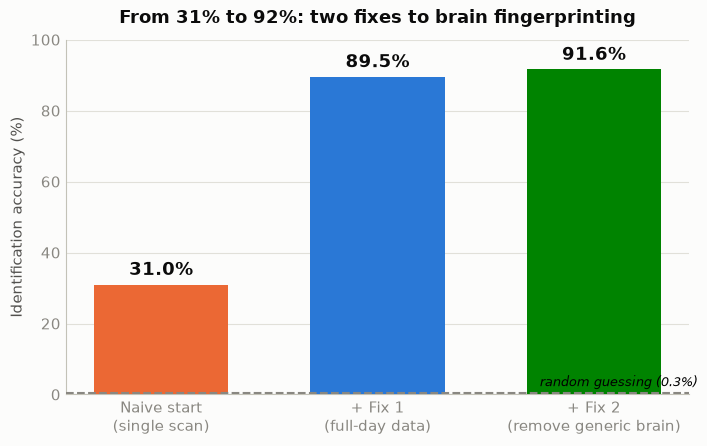

In [ ]:
labels = ["Naive start\n(single scan)", "+ Fix 1\n(full-day data)", "+ Fix 2\n(remove generic brain)"]
vals, colors = [naive_accuracy, fullday_accuracy, backbone_accuracy], [ORANGE, BLUE, GREEN]
fig, ax = plt.subplots(figsize=(7.2, 4.6))
bars = ax.bar(labels, [v * 100 for v in vals], color=colors, width=0.62, zorder=3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v * 100 + 1.5, f"{v*100:.1f}%",
            ha="center", va="bottom", fontsize=13, fontweight="bold", color=INK)
# above the bars (zorder 3), or the line only shows in the gaps between them
ax.axhline(chance * 100, ls="--", lw=1.5, color=MUTED, zorder=4)
ax.text(2.48, chance * 100 + 1.2, "random guessing (0.3%)", ha="right", va="bottom",
        fontsize=9, color="black", style="italic", zorder=4)
ax.set_ylim(0, 100); ax.set_ylabel("Identification accuracy (%)")
ax.set_title("From 31% to 92%: two fixes to brain fingerprinting", fontweight="bold", pad=12)
ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True); ax.tick_params(length=0)
fig.tight_layout()
plt.show()

### Is the final accuracy truly better than chance?

The analytical chance level (1/339 ≈ 0.3%) provides a useful intuition, but it relies on theoretical assumptions about the data. To obtain a more realistic estimate of chance performance, we use a permutation test.

By randomly shuffling the correspondence between Day 1 and Day 2 participants 5,000 times, we generate the distribution of identification accuracies expected if subject identity contained no information. The observed fingerprinting accuracy is then compared with this empirical null distribution.

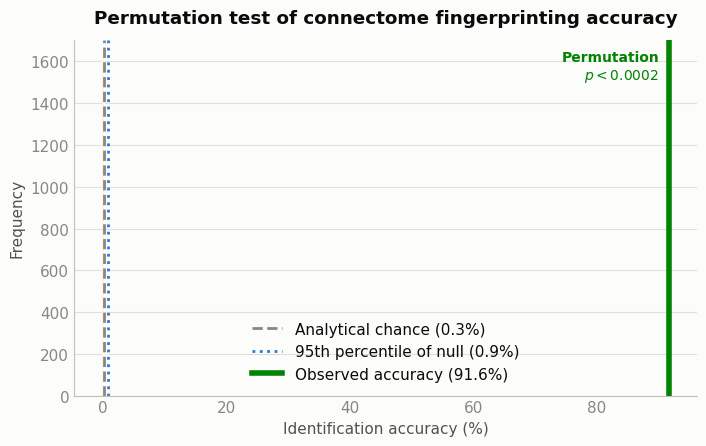

In [ ]:
# Plot the empirical null distribution obtained from permutation testing.

fig, ax = plt.subplots(figsize=(7.2, 4.6))

# Histogram of accuracies expected under the null hypothesis
ax.hist(
    null_distribution * 100,
    bins=30,
    color=ORANGE,
    alpha=0.75,
    edgecolor="white",
)

# Analytical chance level
ax.axvline(
    chance * 100,
    color=MUTED,
    linestyle="--",
    linewidth=2,
    label=f"Analytical chance ({chance*100:.1f}%)",
)

# 95th percentile of the empirical null distribution
null95 = np.percentile(null_distribution, 95)

ax.axvline(
    null95 * 100,
    color=BLUE,
    linestyle=":",
    linewidth=2,
    label=f"95th percentile of null ({null95*100:.1f}%)",
)

# Observed fingerprinting accuracy
ax.axvline(
    observed_accuracy * 100,
    color=GREEN,
    linewidth=4,
    label=f"Observed accuracy ({observed_accuracy*100:.1f}%)",
)

# p sits at the floor the test can resolve when no permutation beat the observed accuracy
resolution_floor = 1 / (len(null_distribution) + 1)
p_label = (f"$p < {resolution_floor:.4f}$" if permutation_p <= resolution_floor
           else f"$p = {permutation_p:.4f}$")

# Annotate statistical significance
ax.text(
    observed_accuracy * 100 - 1.5,
    ax.get_ylim()[1] * 0.97,
    f"Permutation\n{p_label}",
    ha="right",
    va="top",
    fontsize=10,
    color=GREEN,
    fontweight="bold",
)

# Formatting
ax.set_xlabel("Identification accuracy (%)")
ax.set_ylabel("Frequency")
ax.set_title(
    "Permutation test of connectome fingerprinting accuracy",
    fontweight="bold",
    pad=12,
)

ax.grid(axis="y", color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)

ax.legend(frameon=False, loc="lower center")

fig.tight_layout()
plt.show()

**Interpretation**

The orange histogram represents the identification accuracies obtained after randomly shuffling participant identities 5,000 times. This is the empirical null distribution expected if the connectomes carried no subject-specific information.

The green line (observed accuracy) lies far outside this distribution, while the blue line marks the 95th percentile of the null distribution. Since none of the 5,000 permutations achieved an accuracy as high as the observed value, the permutation p-value is < 0.0002, indicating that the observed fingerprinting accuracy is highly unlikely to have occurred by chance.


### The result, as a picture

The result shows up cleanly as a bright diagonal — **almost everybody's best match across
days is themselves.**

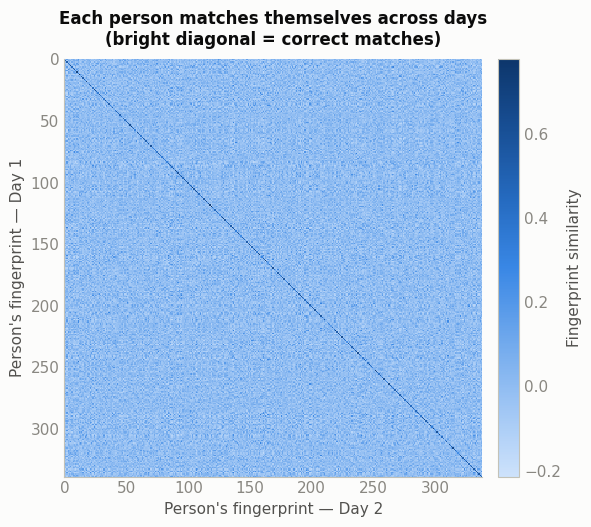

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(similarity_matrix, cmap=SEQ, aspect="equal", interpolation="nearest")
ax.set_xlabel("Person's fingerprint — Day 2"); ax.set_ylabel("Person's fingerprint — Day 1")
ax.set_title("Each person matches themselves across days\n(bright diagonal = correct matches)",
             fontweight="bold", fontsize=12, pad=10); ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03); cb.set_label("Fingerprint similarity", color=INK2)
cb.outline.set_edgecolor(AXIS); cb.ax.tick_params(color=MUTED, labelcolor=MUTED, length=0)
fig.tight_layout()
plt.show()

### Why it works

The diagonal is only meaningful if it's *separated* from everything else — so plot both
populations. Blue is the 339 same-person-across-days similarities (the diagonal); orange is
the 114,582 different-people similarities (everything else).

The two barely overlap. Your two days genuinely look alike; two people genuinely don't. And
the small overlap region is precisely the ~8% we still get wrong.

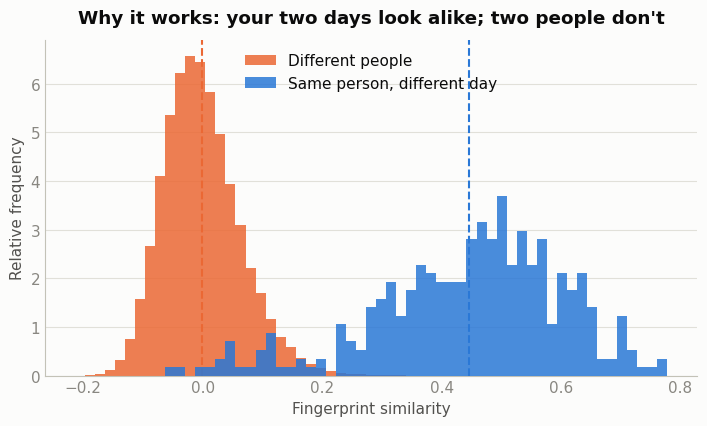

same person, different day : mean similarity +0.446
different people           : mean similarity -0.001


In [ ]:
within = np.diag(similarity_matrix); between = similarity_matrix[~np.eye(N_SUBJECTS, dtype=bool)]
fig, ax = plt.subplots(figsize=(7.2, 4.4))
bins = np.linspace(min(between.min(), within.min()), max(between.max(), within.max()), 60)
ax.hist(between, bins=bins, density=True, color=ORANGE, alpha=0.85, label="Different people", zorder=2)
ax.hist(within, bins=bins, density=True, color=BLUE, alpha=0.85, label="Same person, different day", zorder=3)
ax.axvline(between.mean(), color=ORANGE, lw=1.5, ls="--"); ax.axvline(within.mean(), color=BLUE, lw=1.5, ls="--")
ax.set_xlabel("Fingerprint similarity"); ax.set_ylabel("Relative frequency")
ax.set_title("Why it works: your two days look alike; two people don't", fontweight="bold", pad=12)
ax.legend(frameon=False, loc="upper center"); ax.tick_params(length=0)
ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

print(f"same person, different day : mean similarity {within.mean():+.3f}")
print(f"different people           : mean similarity {between.mean():+.3f}")

**Sections 1 + 2 in one line: 91.6% of 339 people are correctly picked out of a line-up by
their brain's wiring alone.** The rest of the notebook asks what that result is made of.

---
# Section 3 - Which Brain Network is Most Identifiable?

We now have a working identifier, so we can use it as a **measuring instrument**. The 360
regions group into ~12 **networks** — vision, movement, auditory, frontoparietal control,
and so on. If we re-run identification using only *one network's* connections at a time,
whichever network still identifies people well is where identity lives.

The mechanics: every one of the 64,620 fingerprint numbers is a connection between two
regions. A connection is "inside" a network when **both** of its endpoints belong to that
network. So we select those columns and re-run the exact same identification on the smaller
fingerprint. Networks with fewer than 50 internal connections are skipped — too few to give
a stable estimate.

This reuses `day1_deviations` / `day2_deviations`, so no scans are re-read and it's fast.

In [ ]:
print("=== EXTENSION 1 (H3): identifiability by brain network ===")

# Label each of the 64,620 fingerprint edges by the network of its two endpoint regions.
# IU[0]/IU[1] hold the two region indices per edge, in the same order as the fingerprint.
endpoint_a_network = NETWORKS[IU[0]]
endpoint_b_network = NETWORKS[IU[1]]

# For each network, keep only its internal edges and re-run the full identification.
network_accuracy, network_edge_count = {}, {}
for network in sorted(set(NETWORKS)):
    within_network = (endpoint_a_network == network) & (endpoint_b_network == network)
    if within_network.sum() < 50:          # too few edges to give a stable estimate
        continue
    network_accuracy[network] = accuracy(similarity(day1_deviations[:, within_network],
                                                    day2_deviations[:, within_network]))
    network_edge_count[network] = int(within_network.sum())

# Report, most identifiable network first.
ranked = sorted(network_accuracy.items(), key=lambda kv: -kv[1])
for network, acc in ranked:
    print(f"  {network:14s} {acc:5.1%}  ({network_edge_count[network]} connections)")

=== EXTENSION 1 (H3): identifiability by brain network ===
  Posterior-Mu   82.9%  (2926 connections)
  Frontopariet   67.3%  (1225 connections)
  Cingulo-Oper   52.7%  (1540 connections)
  Visual2        49.3%  (1431 connections)
  Default        45.4%  (253 connections)
  Language       35.8%  (253 connections)
  Somatomotor    34.5%  (741 connections)
  Auditory       14.5%  (105 connections)


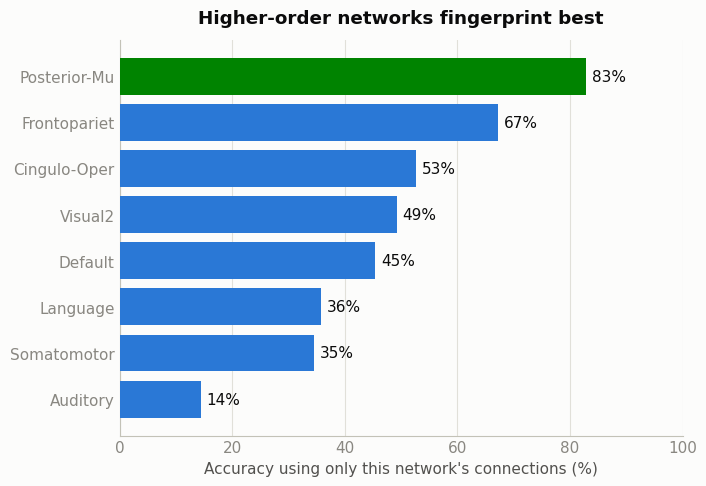

In [ ]:
items = sorted(network_accuracy.items(), key=lambda kv: kv[1])
labels = [k for k, _ in items]; vals = [v * 100 for _, v in items]
colors = [GREEN if v == max(vals) else BLUE for v in vals]
fig, ax = plt.subplots(figsize=(7.2, 5))
bars = ax.barh(labels, vals, color=colors, zorder=3)
for b, v in zip(bars, vals):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.0f}%", va="center", fontsize=11, color=INK)
ax.set_xlim(0, 100); ax.set_xlabel("Accuracy using only this network's connections (%)")
ax.set_title("Higher-order networks fingerprint best", fontweight="bold", pad=12)
ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True); ax.tick_params(length=0)
fig.tight_layout()
plt.show()

### What this says

There's a clear ordering, and it isn't about size — **Posterior-Multimodal identifies people
at 83% from 2,926 connections, while Default manages 45% from 253** and Auditory gets 14%
from 105. Compare the two ends:

- **Top: higher-order association networks.** Posterior-multimodal (83%) and frontoparietal
  (67%) — the systems for flexible, integrative, self-directed thinking. These are the parts
  of the brain whose job is least dictated by the outside world.
- **Bottom: primary sensory and motor networks.** Auditory (14%), somatomotor (35%). These
  do the same job in the same way in everyone — a brain's auditory cortex is built to
  process sound, and there isn't much room for a personal accent in that.

**Identity lives where the brain is least stereotyped.** The frontoparietal result
reproduces Finn et al.'s headline finding.

(A caveat worth stating: these networks differ in how many connections they have, and more
connections generally means a more reliable estimate — so the ranking isn't a *pure* measure
of identity density. Section 4 tests the "maybe it's just more data" worry head-on, with a
cleaner design.)

---
# Section 4 - Cross-Task Identification

So far both fingerprints came from **resting** — people lying still doing nothing. That's a
weak version of the claim, since both scans are the same kind of scan. The stronger claim is
that your fingerprint is a property of *you*, not of the state you were in: it should
persist when your brain is doing something completely different.

So: build a fingerprint per person per task, and match people **across** tasks. Use their
**language**-task fingerprint to find them in a database of **motor**-task fingerprints. If
identity is state-dependent, this should collapse to chance.

The 7 tasks each have 2 runs. We fill a 7×7 grid where entry `[i, j]` = "use task *i*'s run
0 to identify people among task *j*'s run 1". The **diagonal** is same-task identification;
everything **off-diagonal** is cross-task.

This reads every task scan for all 339 people (4,746 scans), so it's the slowest cell here
— roughly half a minute.

In [ ]:
print("=== EXTENSION 2 (H2): cross-task identification ===")

def build_task_fingerprints(run: int) -> list[np.ndarray]:
    """Backbone-removed fingerprint table for the given run of every task.

    Args:
        run: which of each task's two runs to load (0 or 1).

    Returns:
        A list of one (N_SUBJECTS, 64,620) float32 table per task, ordered as in Task.
    """
    # t=t binds the current task into each lambda (else every lambda would see the last t).
    return [remove_backbone(build(lambda s, t=t: load_task_run(s, t, run))).astype(np.float32) for t in Task]


# Fill the 7x7 grid: identify run-0 of task i among run-1 of task j.
run0_by_task = build_task_fingerprints(0)
run1_by_task = build_task_fingerprints(1)
accuracy_grid = np.array([[accuracy(similarity(run0_by_task[i], run1_by_task[j])) for j in Task] for i in Task])

# Same task = diagonal; cross task = everything off the diagonal.
same_task_acc = float(np.mean(np.diag(accuracy_grid)))
cross_task_acc = float(accuracy_grid[~np.eye(len(Task), dtype=bool)].mean())
print(f"  same task (diagonal)     : {same_task_acc:.1%}")
print(f"  different task (off-diag): {cross_task_acc:.1%}  vs chance {chance:.2%}")
print(f"  cross-task is {cross_task_acc / chance:.0f}x chance")

=== EXTENSION 2 (H2): cross-task identification ===
  same task (diagonal)     : 60.6%
  different task (off-diag): 26.1%  vs chance 0.29%
  cross-task is 88x chance


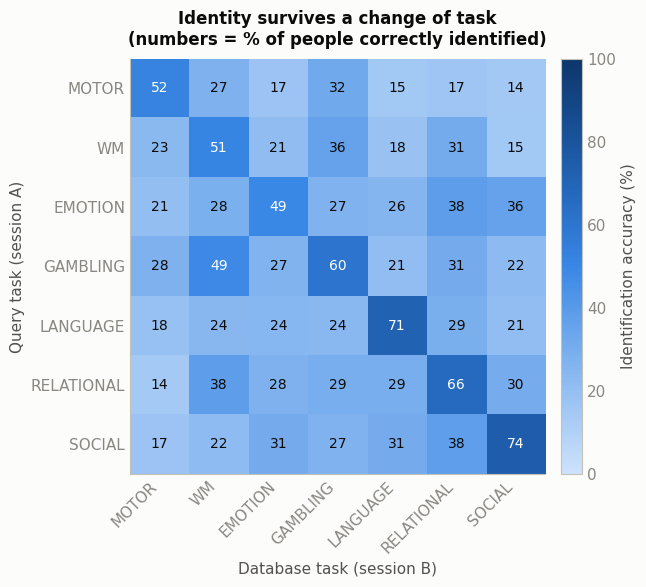

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(accuracy_grid * 100, cmap=SEQ, vmin=0, vmax=100)
ax.set_xticks(range(7)); ax.set_xticklabels(TASKS, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(TASKS)
ax.set_xlabel("Database task (session B)"); ax.set_ylabel("Query task (session A)")
ax.set_title("Identity survives a change of task\n(numbers = % of people correctly identified)",
             fontweight="bold", fontsize=12, pad=10)
for i in range(7):
    for j in range(7):
        v = accuracy_grid[i, j] * 100
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=10,
                color="white" if v > 45 else INK)
ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03); cb.set_label("Identification accuracy (%)", color=INK2)
cb.outline.set_edgecolor(AXIS); cb.ax.tick_params(color=MUTED, labelcolor=MUTED, length=0)
fig.tight_layout()
plt.show()

The diagonal is bright and the off-diagonal is dim — but **the off-diagonal is nowhere near
dark**. At 26% it's roughly **90× chance**. We can take your brain doing a language task and
pick you out of 339 people doing a motor task, one time in four.

**Identity survives a change of mental state.** That's the real claim, and it holds.

One thing to head off: the diagonal (61%) sits well below the 92% we got from rest. That
isn't a regression — it's **Fix 1 unavailable**. Task runs are short (176–405 timepoints vs
rest's ~2400), so every task fingerprint is estimated from a fraction of the data. We're
back in the noisy-snapshot regime that gave us 31% before, and 61% from ~300 timepoints is
the *same method* doing well with less.

## The key insight - identifiability tracks specialisation, not data

Look at the diagonal again and rank the tasks: **social (74%), language (71%), relational
(66%)** at the top; **emotion (49%), working-memory (51%), motor (52%)** at the bottom. The
tasks that make people most identifiable are the **higher-order, cognitively rich** ones —
the same story Section 3 told about networks, from completely independent data.

But there's an obvious objection, and it's the right one to raise: **maybe the winners just
had longer scans.** We just finished arguing that more data → better fingerprints, so if
social happened to be the longest task, the ranking would mean nothing.

So test it directly — correlate each task's accuracy against its scan length.

In [ ]:
# SPECIALISATION: is a task's own-task accuracy just explained by how long its scan was?
# A weak correlation argues accuracy reflects the *type* of processing, not sheer data.
within_task_acc = np.diag(accuracy_grid)
scan_lengths = np.array([load_task_run(0, t, 0).shape[1] for t in Task])  # timepoints per task
length_corr = float(np.corrcoef(scan_lengths, within_task_acc)[0, 1])
print(f"  within-task accuracy vs scan length: correlation r = {length_corr:.2f}")
print("  (weak -> accuracy is NOT just 'more data'; it tracks the type of processing)")
for task_idx in np.argsort(-within_task_acc):   # best-identified task first
    print(f"    {TASKS[task_idx]:11s} {within_task_acc[task_idx]:5.1%}   ({scan_lengths[task_idx]} timepoints)")

  within-task accuracy vs scan length: correlation r = -0.01
  (weak -> accuracy is NOT just 'more data'; it tracks the type of processing)
    SOCIAL      74.0%   (274 timepoints)
    LANGUAGE    71.2%   (316 timepoints)
    RELATIONAL  66.4%   (232 timepoints)
    GAMBLING    60.5%   (253 timepoints)
    MOTOR       51.8%   (284 timepoints)
    WM          51.0%   (405 timepoints)
    EMOTION     49.4%   (176 timepoints)


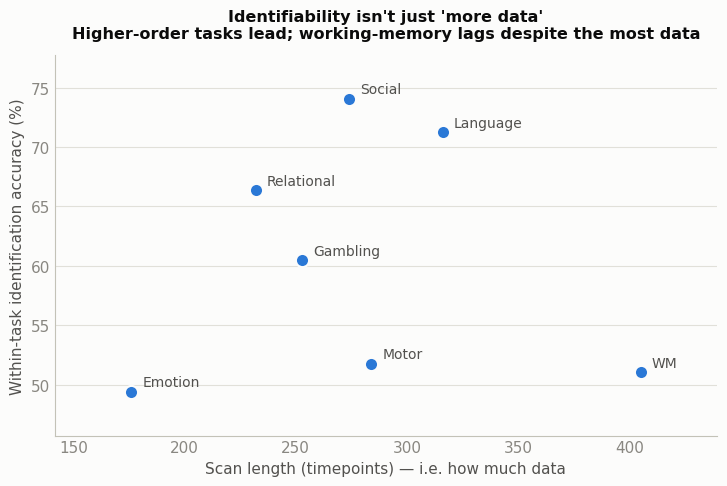

In [ ]:
fig, ax = plt.subplots(figsize=(7.4, 5))
ax.scatter(scan_lengths, within_task_acc * 100, s=90, color=BLUE, zorder=3, edgecolor=SURFACE, linewidth=1.5)
for t in range(7):
    label = TASKS[t] if TASKS[t] == "WM" else TASKS[t].title()
    ax.annotate(label, (scan_lengths[t], within_task_acc[t] * 100),
                textcoords="offset points", xytext=(8, 4), fontsize=10, color=INK2)
ax.set_xlabel("Scan length (timepoints) — i.e. how much data")
ax.set_ylabel("Within-task identification accuracy (%)")
ax.set_title("Identifiability isn't just 'more data'\nHigher-order tasks lead; working-memory lags despite the most data",
             fontweight="bold", fontsize=11.5, pad=12)
ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.margins(0.15)
fig.tight_layout()
plt.show()

**r = −0.01 — essentially zero.** The cloud is flat: scan length explains nothing about
which tasks make people identifiable. The clinching case is **working-memory**, which has
*the most data of any task* (405 timepoints) and still lands near the bottom at 51%, while
**social** leads at 74% with 274.

So the objection is answered, and what's left is the interpretation:

> **Identity lives in the brain's higher-order association systems** — social cognition,
> language, relational reasoning; the frontoparietal and posterior-multimodal networks —
> far more than in primary sensory and motor systems, which are more stereotyped across
> people.

The reason to believe it is that **two independent analyses point the same way**: Section 3
sliced the brain up *anatomically* (by network) and Section 4 sliced it up *functionally*
(by task), and they agree.

---
# Section 5 - Intelligence vs Identifiability

A natural follow-up: if identity lives in the networks for flexible, integrative thinking,
are **cognitively distinctive** brains also **identity-distinctive**?

Two things to build first.

**The cognitive score.** This anonymised release has no IQ field, so we make one. Three
in-scanner tasks load heavily on fluid intelligence in the HCP literature: working-memory
2-back accuracy, relational-reasoning accuracy, and the adaptive difficulty reached on
language-math. Reduce each to one number per person, z-score them onto a common scale, and
average — a standardised general-cognitive composite.

In [ ]:
def load_intelligence() -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Build a per-subject cognitive ('intelligence') score from in-scanner performance.

    There is no IQ field in this anonymised release, so we build a general-cognitive
    composite from three tasks that load heavily on fluid intelligence in the HCP
    literature: working-memory 2-back accuracy, relational-reasoning accuracy, and
    the adaptive language-math difficulty reached. Each subtest is reduced to one
    number per subject, z-scored, and the three are averaged into a standardised
    composite (mean 0; higher = better cognitive performance).

    Returns:
        A 2-tuple of:
          - composite: a (length - N_SUBJECTS) array, the averaged cognitive score
            (NaN where a subject is missing data),
          - subtests: a dict mapping subtest name -> its own (length - N_SUBJECTS) array.
    """
    behavior_dir = os.path.join(DATA, "hcp", "behavior")

    def align_by_subject(per_subject_score: "pd.Series") -> np.ndarray:
        # Force one slot per subject 0..N-1 (NaN where missing) so subtests stay aligned.
        return per_subject_score.reindex(range(N_SUBJECTS)).to_numpy(dtype=float)

    def zscore(values: np.ndarray) -> np.ndarray:
        # Standardise to SD units, ignoring missing subjects.
        return (values - np.nanmean(values)) / np.nanstd(values)

    wm_data         = pd.read_csv(f"{behavior_dir}/wm.csv")
    relational_data = pd.read_csv(f"{behavior_dir}/relational.csv")
    language_data   = pd.read_csv(f"{behavior_dir}/language.csv")

    # Working memory: mean accuracy on the hard 2-back conditions (ignore 0-back baseline).
    two_back_rows     = wm_data[wm_data.ConditionName.str.startswith("2BK")]
    two_back_accuracy = align_by_subject(two_back_rows.groupby("Subject").ACC.mean())

    # Relational reasoning: mean accuracy on the REL condition (ignore the easier MATCH).
    relational_rows     = relational_data[relational_data.ConditionName == "REL"]
    relational_accuracy = align_by_subject(relational_rows.groupby("Subject").ACC.mean())

    # Language: mean adaptive difficulty reached on the MATH condition (harder = better).
    math_rows       = language_data[language_data.ConditionName == "MATH"]
    math_difficulty = align_by_subject(math_rows.groupby("Subject").AVG_DIFFICULTY_LEVEL.mean())

    subtests = {"working_memory_2back": two_back_accuracy,
                "relational_reasoning": relational_accuracy,
                "language_math_difficulty": math_difficulty}

    # Put the three subtests on a common scale, then average across them per subject.
    standardised = np.vstack([zscore(two_back_accuracy),
                              zscore(relational_accuracy),
                              zscore(math_difficulty)])
    composite = np.nanmean(standardised, axis=0)
    return composite, subtests


intelligence, subtests = load_intelligence()
print(f"cognitive composite for {np.isfinite(intelligence).sum()} people "
      f"(mean {np.nanmean(intelligence):+.2f}, SD {np.nanstd(intelligence):.2f})")

cognitive composite for 339 people (mean +0.00, SD 0.73)


**A better identifiability measure.** "Did we identify them: yes/no" throws away almost
everything — it can't tell a person who barely won from one who won by a mile. Instead we
measure how far each person's own across-day match sits above their *impostor* crowd, in
standard deviations. That turns identifiability into a graded per-person score.

In [ ]:
def compute_self_identifiability(similarity_matrix: np.ndarray) -> np.ndarray:
    """Per-subject distinctiveness: how far each subject's own match sits above impostors.

    For subject i the 'self match' is the diagonal entry (their day-1 vs day-2 similarity).
    The impostors are the off-diagonal entries in that subject's row (querying day 1 against
    everyone's day 2) and column (the reverse). We z-score the self match against the
    impostor cloud in each direction and average the two, giving a graded score in SD units
    (higher = more uniquely identifiable) rather than a plain yes/no.

    Args:
        similarity_matrix: the (N_SUBJECTS, N_SUBJECTS) cross-day grid.

    Returns:
        A length-N_SUBJECTS array of distinctiveness scores, in standard deviations.
    """
    off_diagonal = ~np.eye(N_SUBJECTS, dtype=bool)    # True everywhere except the self-matches
    self_match = np.diag(similarity_matrix)           # each subject's own across-day similarity

    # Impostor cloud stats, treating each subject first as a day-1 query (their row)...
    row_impostor_mean = np.array([similarity_matrix[i, off_diagonal[i]].mean() for i in range(N_SUBJECTS)])
    row_impostor_std  = np.array([similarity_matrix[i, off_diagonal[i]].std()  for i in range(N_SUBJECTS)])
    # ...then as a day-2 query (their column).
    col_impostor_mean = np.array([similarity_matrix[off_diagonal[:, j], j].mean() for j in range(N_SUBJECTS)])
    col_impostor_std  = np.array([similarity_matrix[off_diagonal[:, j], j].std()  for j in range(N_SUBJECTS)])

    # Self match's distance above the impostors, in SDs, averaged over both directions.
    return 0.5 * ((self_match - row_impostor_mean) / row_impostor_std
                  + (self_match - col_impostor_mean) / col_impostor_std)


def compute_identified(similarity_matrix: np.ndarray) -> np.ndarray:
    """Per-subject boolean: was this subject the top match in BOTH directions?

    Args:
        similarity_matrix: the (N_SUBJECTS, N_SUBJECTS) cross-day grid.

    Returns:
        A length-N_SUBJECTS boolean array, True where the subject is their own best match
        both when querying day 1 -> day 2 and day 2 -> day 1.
    """
    truth = np.arange(N_SUBJECTS)
    row_correct = similarity_matrix.argmax(1) == truth   # best day-2 match for each day-1 subject
    col_correct = similarity_matrix.argmax(0) == truth   # best day-1 match for each day-2 subject
    return row_correct & col_correct


self_identifiability = compute_self_identifiability(similarity_matrix)
identified = compute_identified(similarity_matrix)

print(f"self-identifiability: {self_identifiability.min():.1f} to {self_identifiability.max():.1f} SDs "
      f"above the impostor crowd (median {np.median(self_identifiability):.1f})")
print(f"identified in both directions: {identified.sum()}/{N_SUBJECTS}")

self-identifiability: -0.6 to 16.5 SDs above the impostor crowd (median 7.4)
identified in both directions: 306/339


Now correlate the two. We use three tests because there are two different measures in play:
**Pearson** (a straight-line relationship) and **Spearman** (any consistently increasing
one, robust to outliers) for the graded score, and **point-biserial** for the strict yes/no.
If there's a relationship, at least one should find it.

In [ ]:
print("=== EXTENSION 3: identifiability vs intelligence ===")

# Correlate each measure against the cognitive composite, over subjects that have one.
# (Pearson + Spearman suit the continuous score; point-biserial suits the binary one.)
has_intelligence = np.isfinite(intelligence)
pearson_r, pearson_p = stats.pearsonr(intelligence[has_intelligence], self_identifiability[has_intelligence])
spearman_rho, spearman_p = stats.spearmanr(intelligence[has_intelligence], self_identifiability[has_intelligence])
pointbiserial_r, pointbiserial_p = stats.pointbiserialr(identified[has_intelligence].astype(float),
                                                        intelligence[has_intelligence])
iq_identified = intelligence[has_intelligence & identified]
iq_missed     = intelligence[has_intelligence & ~identified]

print(f"  self-identifiability vs IQ : Pearson r = {pearson_r:+.3f} (p = {pearson_p:.3g}) | "
      f"Spearman rho = {spearman_rho:+.3f} (p = {spearman_p:.3g})")
print(f"  identified-correctly vs IQ : point-biserial r = {pointbiserial_r:+.3f} (p = {pointbiserial_p:.3g})")
print(f"  mean IQ  identified={iq_identified.mean():+.3f} (n={iq_identified.size})  "
      f"missed={iq_missed.mean() if iq_missed.size else float('nan'):+.3f} (n={iq_missed.size})")

# Break the continuous relationship down by individual subtest.
print("  per-subtest Pearson r with self-identifiability:")
subtest_correlations = {}
for subtest_name, subtest_scores in subtests.items():
    valid_subtest = has_intelligence & np.isfinite(subtest_scores)
    r, p = stats.pearsonr(subtest_scores[valid_subtest], self_identifiability[valid_subtest])
    subtest_correlations[subtest_name] = {"r": float(r), "p": float(p)}
    print(f"    {subtest_name:26s} r = {r:+.3f} (p = {p:.3g})")

=== EXTENSION 3: identifiability vs intelligence ===
  self-identifiability vs IQ : Pearson r = +0.041 (p = 0.449) | Spearman rho = +0.049 (p = 0.365)
  identified-correctly vs IQ : point-biserial r = +0.014 (p = 0.792)
  mean IQ  identified=+0.004 (n=306)  missed=-0.032 (n=33)
  per-subtest Pearson r with self-identifiability:
    working_memory_2back       r = +0.003 (p = 0.95)
    relational_reasoning       r = +0.068 (p = 0.21)
    language_math_difficulty   r = +0.017 (p = 0.753)


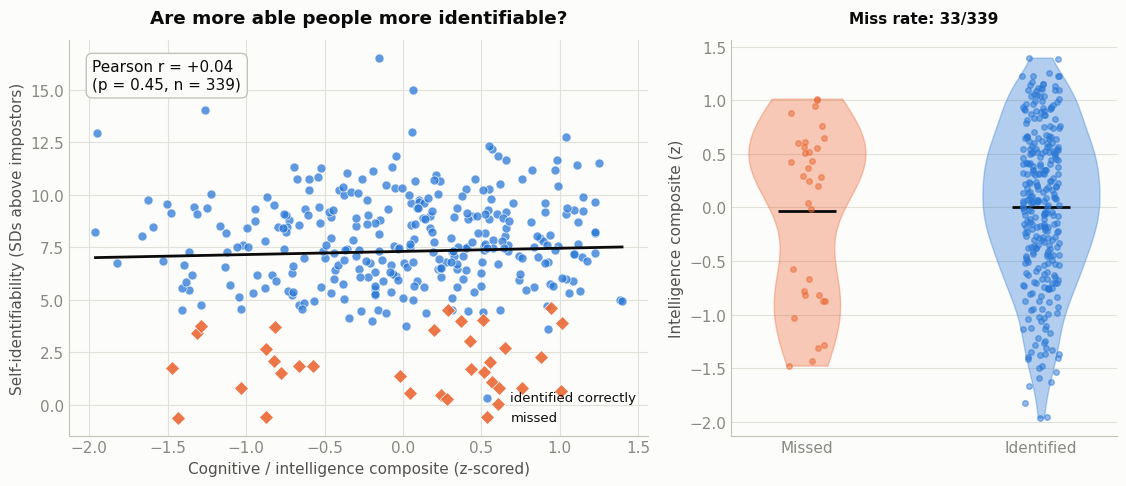

In [ ]:
valid = np.isfinite(intelligence)
x, y = intelligence[valid], self_identifiability[valid]
hit = identified[valid]
hi = intelligence[valid & identified]; lo = intelligence[valid & ~identified]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.4, 5), gridspec_kw={"width_ratios": [1.5, 1]})
ax.scatter(x[hit], y[hit], s=42, color=BLUE, alpha=0.75, edgecolor=SURFACE,
           linewidth=0.6, zorder=3, label="identified correctly")
ax.scatter(x[~hit], y[~hit], s=52, color=ORANGE, alpha=0.9, edgecolor=SURFACE,
           linewidth=0.6, zorder=4, marker="D", label="missed")
b, a = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b * xs, color=INK, lw=2, zorder=5)
ax.text(0.04, 0.95, f"Pearson r = {pearson_r:+.2f}\n(p = {pearson_p:.2g}, n = {valid.sum()})",
        transform=ax.transAxes, va="top", ha="left", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", fc=SURFACE, ec=AXIS, lw=1))
ax.set_xlabel("Cognitive / intelligence composite (z-scored)")
ax.set_ylabel("Self-identifiability (SDs above impostors)")
ax.set_title("Are more able people more identifiable?", fontweight="bold", pad=12)
ax.legend(frameon=False, loc="lower right", fontsize=9.5)
ax.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True); ax.tick_params(length=0)

# right panel: IQ of correctly-identified vs missed
parts = [lo, hi] if lo.size else [hi]
labels = (["Missed", "Identified"] if lo.size else ["Identified"])
cols = ([ORANGE, BLUE] if lo.size else [BLUE])
vp = ax2.violinplot(parts, showmeans=True, showextrema=False)
for body, c in zip(vp["bodies"], cols):
    body.set_facecolor(c); body.set_alpha(0.35); body.set_edgecolor(c)
vp["cmeans"].set_color(INK); vp["cmeans"].set_linewidth(2)
for k, (data, c) in enumerate(zip(parts, cols), start=1):
    jit = k + (np.random.RandomState(0).rand(data.size) - 0.5) * 0.16
    ax2.scatter(jit, data, s=16, color=c, alpha=0.5, zorder=3)
ax2.set_xticks(range(1, len(labels) + 1)); ax2.set_xticklabels(labels)
ax2.set_ylabel("Intelligence composite (z)")
ax2.set_title(f"Miss rate: {(~hit).sum()}/{valid.sum()}", fontweight="bold", fontsize=11, pad=12)
ax2.grid(True, axis="y", color=GRID, lw=0.8, zorder=0); ax2.set_axisbelow(True); ax2.tick_params(length=0)
fig.tight_layout()
plt.show()

### A clean null

**No relationship** — Pearson r = +0.04, p = 0.45. The regression line is flat, all three
tests agree, no subtest rescues it, and the 33 people we missed span the full ability range
(the two violins sit on top of each other).

A null result is only worth reporting if the study could have found the effect. This one
could: at **n = 339** the design has roughly **80% power to detect even r ≈ 0.15**, so we'd
have seen a weak effect if one existed. This is a real absence, not a failure to look.

And the absence is informative in two ways:

1. **The fingerprint identifies *the person*, not a "smart brain" signal.** For a biometric
   this is exactly what you want — an identity system that quietly ranked people by
   cognitive ability would be encoding something it has no business encoding. This one
   doesn't.
2. **It sharpens Sections 3 and 4.** Identity concentrates in the higher-order networks and
   tasks — but *within* those systems, what makes you identifiable is **idiosyncratic
   wiring, not general ability**. Being distinctive and being able are different things.

---
# Section 6 - Summary

## What we found

| Question | Answer |
|---|---|
| Can we identify someone from their connectome across days? | **Yes — 91.6%**, vs 0.3% chance |
| What made the difference? | Data preparation: one scan → a full day (31% → 89.5%), then removing the generic brain (→ 91.6%) |
| Which brain networks carry identity? | Higher-order association: posterior-multimodal **83%**, frontoparietal **67%**. Not primary sensory: auditory **14%** |
| Does identity survive a change of task? | **Yes — 26%** cross-task, ~90× chance |
| Is that just "more data"? | **No** — accuracy vs scan length is r = **−0.01** |
| Are smarter people more identifiable? | **No** — r = +0.04, p = 0.45, a well-powered null |

**The through-line:** your brain's identity lives in its **higher-order association
systems** — the flexible, integrative, self-directed parts — and not in the primary sensory
and motor systems that do the same stereotyped job in everyone. Two independent analyses
(by network, and by task) agree, a confound check rules out the obvious alternative
explanation, and the intelligence null rules out ability as the hidden variable.

## Why the numbers are trustworthy

- **Chance is stated everywhere** (0.3%), and both matching directions are scored and agree.
- **No leakage.** Identity labels never enter any transform. Day 1 and Day 2 are processed
  separately. For the cross-task work each person is wholly in the query *or* the database.
- **The phase-encoding confound** was identified and controlled (part of Fix 1).
- **The specialisation insight has a confound check** — the r = −0.01 scan-length control.
- **The null is well-powered** and reported as a genuine absence.

## Where to go next

- **[Amico & Goñi 2018](https://www.nature.com/articles/s41598-018-25089-1)**, *Scientific
  Reports* — "differential identifiability": reconstruct fingerprints from their leading
  principal components and keep only the components that carry identity. The natural next
  extension, and it pushes accuracy higher still.
- **Fix 2, generalised.** We subtracted the group mean. Subtracting a *projection* onto the
  leading shared components is the same idea with a sharper knife.
- **Reliability.** Noble, Scheinost & Constable 2021, *NeuroImage* — how much scan time you
  actually need before a connectome estimate is stable.

## References

- **Finn et al. 2015**, *Nature Neuroscience* — connectome fingerprinting; the frontoparietal finding.
- **Glasser et al. 2016**, *Nature* — the 360-region atlas.
- **Amico & Goñi 2018**, *Scientific Reports* — "differential identifiability".
- **Noble, Scheinost & Constable 2021**, *NeuroImage* — reliability of connectome-based measures.

